### HyDE
 What is HyDe?

HyDE (Hypothetical Document Embeddings) is a retrieval technique where, instead of embedding the user’s query directly, you first generate a hypothetical answer (document) to the query using an LLM — and then embed that hypothetical document to search your vector store.

 HyDE bridges the gap between user intent and relevant content, especially when:

1. Queries are short
2. Language mismatch between query and documents
3.You want to retrieve based on answer content, not question words

In [1]:
from langchain_community.document_loaders import WikipediaLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import Chroma

In [2]:
# 1. Load and chunk your data
loader = WikipediaLoader(query="Abdul Kalam", load_max_docs=5)
documents = loader.load()

text_splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=100)
docs = text_splitter.split_documents(documents)
docs

[Document(metadata={'title': 'A. P. J. Abdul Kalam', 'summary': 'Avul Pakir Jainulabdeen Abdul Kalam (  UB-duul kə-LAHM; 15 October 1931 – 27 July 2015) was an Indian aerospace scientist and statesman who served as the  president of India from 2002 to 2007.\nBorn and raised in a Muslim family in Rameswaram, Tamil Nadu, Kalam studied physics and aerospace engineering. He spent the next four decades as a scientist and science administrator, mainly at the Defence Research and Development Organisation (DRDO) and Indian Space Research Organisation (ISRO) and was intimately involved in India\'s civilian space programme and military missile development efforts. He was known as the "Missile Man of India" for his work on the development of ballistic missile and launch vehicle technology. He also played a pivotal organisational, technical, and political role in Pokhran-II nuclear tests in 1998, India\'s second such test after the first test in 1974.\nKalam was elected as the president of India i

In [ ]:
# 2. Create your vectorstore

from langchain_community.vectorstores import FAISS

embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
vectorstore = FAISS.from_documents(docs, embeddings)

In [ ]:
# 3.Setup LLM for generting hypothetical answers

import os
from dotenv import load_dotenv
load_dotenv()
from langchain.chat_models import init_chat_model

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
llm = init_chat_model(
    model="groq/compound-mini",
    model_provider="groq",
    api_key=os.getenv("GROQ_API_KEY")
)
llm

ChatGroq(profile={}, client=<groq.resources.chat.completions.Completions object at 0x0000015D767E8B60>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000015D00489AC0>, model_name='groq/compound-mini', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [8]:
db = Chroma.from_documents(docs, embeddings, persist_directory="output/abdul_kalam_for_hyde.db")
base_retriever = db.as_retriever(search_kwargs={"k": 5})

In [11]:
from langchain_core.output_parsers import StrOutputParser
## Generating a prompt for generating HyDE
from langchain_core.prompts.chat import ChatPromptTemplate, SystemMessagePromptTemplate, HumanMessagePromptTemplate

def get_hyde_doc(query: str) -> str:
    template = """Imagine you are a expert writing a breif explanation on topic : '{query}' .
    create a hypothetical answer for the topic."""

    system_message_prompt = SystemMessagePromptTemplate.from_template(template = template)
    human_message = HumanMessagePromptTemplate.from_template("{query}")
    chat_prompt = ChatPromptTemplate.from_messages([system_message_prompt, human_message])
    message = chat_prompt.format_prompt(query=query).to_messages()
    print(message)
    response = llm.invoke(message)
    hype_doc = response.content
    return hype_doc

In [12]:
query = 'What are the Missiles developed by Abdul Kalam?'
print(get_hyde_doc(query=query))

[SystemMessage(content="Imagine you are a expert writing a breif explanation on topic : 'What are the Missiles developed by Abdul Kalam?' .\n    create a hypothetical answer for the topic.", additional_kwargs={}, response_metadata={}), HumanMessage(content='What are the Missiles developed by Abdul Kalam?', additional_kwargs={}, response_metadata={})]
**Missiles that came out of Dr A.P.J. Abdul Kalam’s leadership**

| Missile | Type / Role | Key Features | First Test / Service |
|---------|-------------|--------------|----------------------|
| **Prithvi** | Short‑range surface‑to‑surface (SSM) | Liquid‑propellant, range 150–350 km, can carry conventional or nuclear warheads; variants Prithvi‑I (Army), Prithvi‑II (Navy), Prithvi‑III (Air Force) | 1988 (Prithvi‑I) |
| **Agni** | Long‑range ballistic missile (IRBM/ICBM family) | Solid‑propellant (later versions), range 700 km → 5,000 km, road‑mobile; forms the backbone of India’s strategic deterrent | 1989 (Agni‑I) |
| **Akash** | Medium‑r

In [13]:
matched_doc = base_retriever.invoke(get_hyde_doc(query))
print(matched_doc)

[SystemMessage(content="Imagine you are a expert writing a breif explanation on topic : 'What are the Missiles developed by Abdul Kalam?' .\n    create a hypothetical answer for the topic.", additional_kwargs={}, response_metadata={}), HumanMessage(content='What are the Missiles developed by Abdul Kalam?', additional_kwargs={}, response_metadata={})]
[Document(metadata={'title': 'List of awards and honours received by A. P. J. Abdul Kalam', 'summary': 'A. P. J. Abdul Kalam was an Indian aerospace scientist and statesman who served as president of India from 2002 to 2007. Born in Rameswaram in Southern India, Kalam spent four decades as a scientist and science administrator, mainly at the Defence Research and Development Organisation and Indian Space Research Organisation and was intimately involved in India\'s civilian space programme and military missile development efforts. He was known as the "Missile Man of India" for his work on the development of ballistic missile and launch vehi

### Langchain-HypotheticalDocumentEmbedder

In [14]:
from langchain_classic.chains.hyde.base import HypotheticalDocumentEmbedder

from langchain_core.prompts import PromptTemplate
from langchain_community.vectorstores import Chroma
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_classic.chains.combine_documents import create_stuff_documents_chain

# Step 1: Load and split documents
loader = TextLoader("langchain_crewai_dataset.txt")
docs = loader.load()
splitter = RecursiveCharacterTextSplitter(chunk_size=300, chunk_overlap=50)
chunks = splitter.split_documents(docs)

In [ ]:

# Step 2: Create embeddings
base_embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

C:\Users\FPK1COB\AppData\Local\Temp\ipykernel_7368\3852879721.py:1: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  base_embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")


According to the official documentation and LangChain source code (mapping in PROMPT_MAP), the default options are:

- web_search
- sci_fact
- arguana
- trec_covid
- fiqa
- dbpedia_entity
- trec_news
- mr_tydi

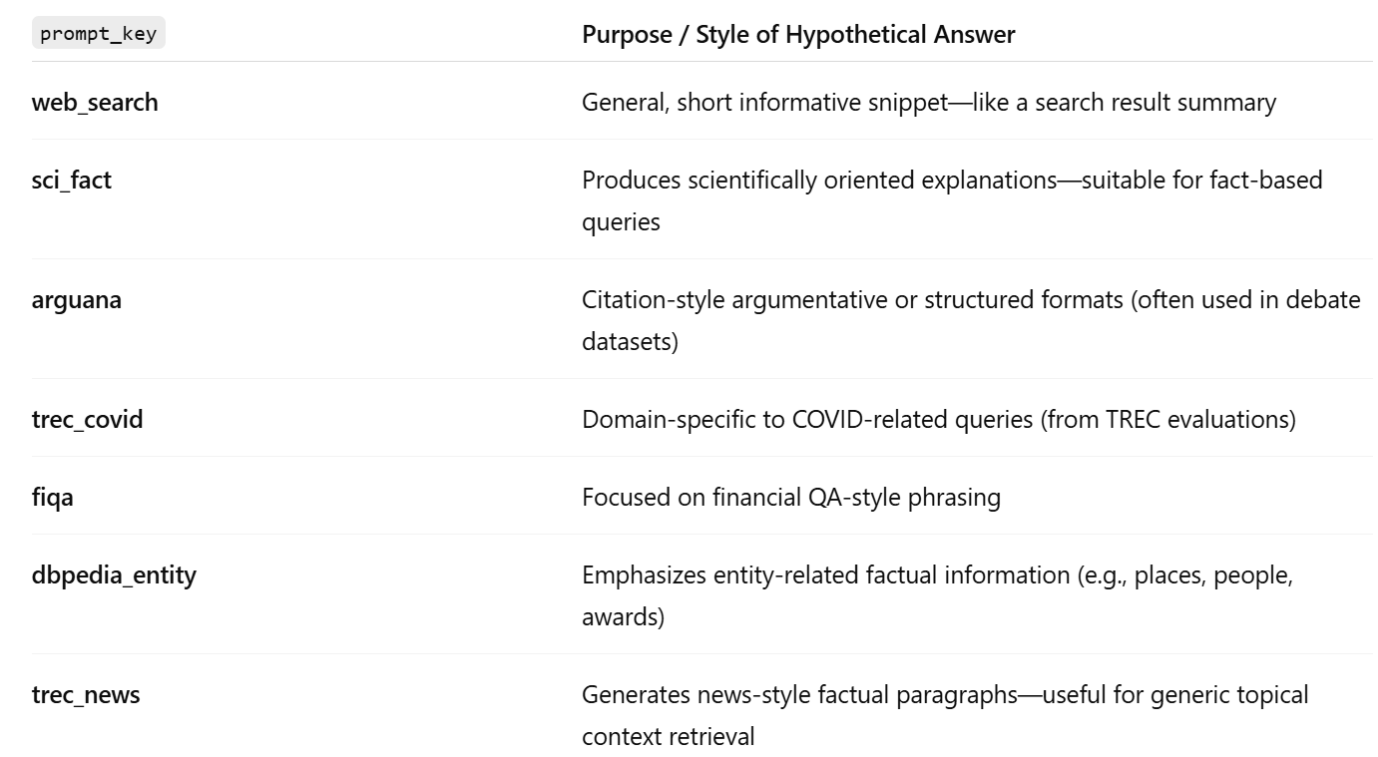

In [19]:
# Step 3: Create HyDE document generator

hyde_embedding_generator = HypotheticalDocumentEmbedder.from_llm(
    llm=llm,
    base_embeddings=base_embeddings,
    prompt_key='web_search',
)

In [25]:
# Step 4: Create vectorstore and retriever
vectorstore = Chroma.from_documents(
    documents=chunks,
    embedding=hyde_embedding_generator,
    persist_directory="output/langchain"
)

In [26]:
# Step 5: RAG answer generation prompt
rag_prompt = PromptTemplate.from_template("""
Use the context below to answer the question.

Context:
{context}

Question: {input}
""")
rag_chain = create_stuff_documents_chain(llm=llm, prompt=rag_prompt)

In [29]:
# Step 6 : Create RAG Pipeline
def hyde_rag_pipeline(query):
    matched_docs = vectorstore.similarity_search(query, k=5)
    print("Matched Docs: ", matched_docs)
    response = rag_chain.invoke({
        "input": query,
        "context": matched_docs
    })
    return response

# or you can use the retriever interface of vectorstore
def hyde_rag_pipeline_with_retriever(query):
    base_retriever = vectorstore.as_retriever(search_kwargs={"k": 5})
    matched_docs = base_retriever.invoke(query)
    print("Matched Docs: ", matched_docs)
    response = rag_chain.invoke({
        "input": query,
        "context": matched_docs
    })
    return response

In [28]:
# Step 7: Run example query
query = "What memory modules does LangChain provide?"
answer = hyde_rag_pipeline(query)
print("Final Answer:\n", answer)

Matched Docs:  [Document(metadata={'source': 'langchain_crewai_dataset.txt'}, page_content='LangChain offers memory modules like ConversationBufferMemory and ConversationSummaryMemory. These allow the LLM to maintain awareness of previous conversation turns or summarize long interactions to fit within token limits. (v1)'), Document(metadata={'source': 'langchain_crewai_dataset.txt'}, page_content='LangChain offers memory modules like ConversationBufferMemory and ConversationSummaryMemory. These allow the LLM to maintain awareness of previous conversation turns or summarize long interactions to fit within token limits. (v1)'), Document(metadata={'source': 'langchain_crewai_dataset.txt'}, page_content='LangChain offers memory modules like ConversationBufferMemory and ConversationSummaryMemory. These allow the LLM to maintain awareness of previous conversation turns or summarize long interactions to fit within token limits. (v10)'), Document(metadata={'source': 'langchain_crewai_dataset.t

In [30]:
query = "What memory modules does LangChain provide?"
answer = hyde_rag_pipeline_with_retriever(query)
print("Final Answer:\n", answer)

Matched Docs:  [Document(metadata={'source': 'langchain_crewai_dataset.txt'}, page_content='LangChain offers memory modules like ConversationBufferMemory and ConversationSummaryMemory. These allow the LLM to maintain awareness of previous conversation turns or summarize long interactions to fit within token limits. (v4)'), Document(metadata={'source': 'langchain_crewai_dataset.txt'}, page_content='LangChain offers memory modules like ConversationBufferMemory and ConversationSummaryMemory. These allow the LLM to maintain awareness of previous conversation turns or summarize long interactions to fit within token limits. (v4)'), Document(metadata={'source': 'langchain_crewai_dataset.txt'}, page_content='LangChain offers memory modules like ConversationBufferMemory and ConversationSummaryMemory. These allow the LLM to maintain awareness of previous conversation turns or summarize long interactions to fit within token limits. (v5)'), Document(metadata={'source': 'langchain_crewai_dataset.tx

### Custom Prompt

In [24]:
from langchain_core.prompts import PromptTemplate

custom = PromptTemplate.from_template(
    "Generate a concise hypothetical answer for this topic: {query}"
)

hyde_embedding_function = HypotheticalDocumentEmbedder.from_llm(
    llm=llm,
    base_embeddings=base_embeddings,
    custom_prompt=custom,
)

In [31]:
custom_vectorstore = Chroma.from_documents(
    documents=chunks,
    embedding=hyde_embedding_function,
    persist_directory="output/langchain_custom_hyde.db"
)

In [32]:
def hyde_rag_pipeline(query):
    matched_docs = custom_vectorstore.similarity_search(query, k=5)
    print("Matched Docs: ", matched_docs)
    response = rag_chain.invoke({
        "input": query,
        "context": matched_docs
    })
    return response

In [33]:
query = "What memory modules does LangChain provide?"
answer = hyde_rag_pipeline(query)
print("Final Answer:\n", answer)

Matched Docs:  [Document(metadata={'source': 'langchain_crewai_dataset.txt'}, page_content='LangChain offers memory modules like ConversationBufferMemory and ConversationSummaryMemory. These allow the LLM to maintain awareness of previous conversation turns or summarize long interactions to fit within token limits. (v10)'), Document(metadata={'source': 'langchain_crewai_dataset.txt'}, page_content='LangChain offers memory modules like ConversationBufferMemory and ConversationSummaryMemory. These allow the LLM to maintain awareness of previous conversation turns or summarize long interactions to fit within token limits. (v1)'), Document(metadata={'source': 'langchain_crewai_dataset.txt'}, page_content='LangChain offers memory modules like ConversationBufferMemory and ConversationSummaryMemory. These allow the LLM to maintain awareness of previous conversation turns or summarize long interactions to fit within token limits. (v4)'), Document(metadata={'source': 'langchain_crewai_dataset.t